In [5]:
import ROOT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from utils.utils import read_root_file, read_lumi_data, prepare_data, weighted_average

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# cuts = {"B_J1_mass": (2.7, 3.5), "B_Mu1_pt": (7, None), "B_Mu2_pt": (7, None), "Run": (370092, None)}
cuts = {"B_J1_mass": (2.7, 3.5), "B_Mu1_pt": (5000, None), "B_Mu2_pt": (5000, None)}
# root_file_path = "../../preselection/parkingDoubleMuonLowMass/2023/v2/PDMLM_mm_2023D_v2.root"
root_file_path = "../../preselection/parkingDoubleMuonLowMass/2023/v4/PDMLM_mm_2023C_v4.root"
run, lumiblock, mass = read_root_file(root_file_path, cuts)

lumi_file = '../../preselection/parkingDoubleMuonLowMass/2023/v4/lumi_normtagBRIL_PDMLM_2023C.csv'
lumi_df = read_lumi_data(lumi_file)

Available branches: ['Run', 'LumiBlock', 'Event', 'B_J1_mass', 'B_J1_pt', 'B_Mu1_pt', 'B_Mu2_pt', 'B_Mu1_eta', 'B_Mu2_eta']


In [4]:
df, prescale_lines = prepare_data(run, lumiblock, mass_range=(2.7, 3.5), mass=mass, lumi_df=lumi_df, count_method='fit')

Using mass range (2.7, 3.5)
Performing ML fit
bin (367770, 0) — Not enough statistics for the ML fit
bin (367770, 1)
bin (367770, 2)
bin (367770, 3)
bin (367771, 0)
bin (367771, 1)
bin (367772, 0)
bin (367790, 0)
bin (367790, 1)
bin (367790, 2)
bin (367790, 3)
bin (367831, 1)
bin (367831, 2)
bin (367831, 3)
bin (367831, 4)
bin (367831, 5)
bin (367831, 6)
bin (367831, 7)
bin (367831, 8)
bin (367831, 9)
bin (367831, 10)
bin (367836, 0) — Not enough statistics for the ML fit
bin (367836, 1)
bin (367836, 2)
bin (367836, 3)
bin (367836, 4)
bin (367836, 5)
bin (367836, 6)
bin (367836, 7)
bin (367836, 8)
bin (367836, 9)
bin (367836, 10)
bin (367836, 11)
bin (367838, 0)
bin (367838, 1)
bin (367838, 2)
bin (367838, 3)
bin (367838, 4)
bin (367838, 5)
bin (367838, 6)
bin (367838, 7)
bin (367838, 8)
bin (367838, 9)
bin (367838, 10)
bin (367838, 11)
bin (367838, 12)
bin (367838, 13)
bin (367838, 14)
bin (367838, 15)
bin (367840, 0)
bin (367840, 1)
bin (367840, 2)
bin (367840, 3)
bin (367840, 4)
bin

Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367770_50.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367770_100.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367770_150.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367771_0.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367771_50.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367772_0.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367790_0.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367790_50.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367790_100.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367790_150.png has been created
Info in <TCanvas::Print>: png file plots/ML_fits/ML_fit_bin_367831_50.png has been create

In [12]:
df = pd.read_csv("event_data.csv")
df

,run,lumiblock,x_label,event_y,event_y_error,lumi_y,pileup_y,nlumis,chi2,alpha,...,n,n_err,nbkg,nbkg_err,nsig,nsig_err,sigma,sigma_err,sigma2,sigma2_err
0,367770,0,367770_0,-1.000000,-1.000000,108.171698,15.333333,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,367770,50,367770_50,63022.912446,427.678047,194.853451,26.488000,50,1.490106,1.856819,...,1.047772,0.175115,9724.213646,359.880516,63022.912446,427.678047,0.021623,0.000380,0.042716,0.000697
2,367770,100,367770_100,91968.216527,629.334435,298.582655,40.622000,50,2.013184,1.880378,...,1.147491,0.276306,15350.932033,565.142491,91968.216527,629.334435,0.021713,0.000326,0.043062,0.000719
3,367770,150,367770_150,113304.236328,467.997008,400.658978,56.110204,49,2.329863,1.646826,...,1.616027,0.172735,19704.582831,354.132429,113304.236328,467.997008,0.021514,0.000301,0.041455,0.000578
4,367771,0,367771_0,122131.451116,440.764989,452.831822,62.571429,49,2.231128,1.671848,...,1.628944,0.111084,22050.568920,306.574939,122131.451116,440.764989,0.021745,0.000269,0.041907,0.000547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674,368822,800,368822_800,114440.909674,540.245535,432.364104,60.240000,50,2.093352,1.870138,...,1.136049,0.149121,19664.136230,443.920243,114440.909674,540.245535,0.021336,0.000292,0.041240,0.000556
675,368822,850,368822_850,115855.049182,1795.864981,429.896964,58.486000,50,1.746865,1.899831,...,1.000000,0.134149,18563.216249,1791.289272,115855.049182,1795.864981,0.021478,0.000305,0.042059,0.000891
676,368822,900,368822_900,108841.939964,944.342346,405.172337,56.618367,49,1.893992,1.897261,...,1.009602,1.329983,17336.349212,975.721927,108841.939964,944.342346,0.021572,0.000189,0.042064,0.000377
677,368822,950,368822_950,93039.199587,414.146942,400.767978,55.138095,42,1.922408,1.720977,...,1.313622,0.107131,16009.639197,307.059087,93039.199587,414.146942,0.020881,0.000335,0.040604,0.000579


In [13]:
df.columns

Index(['run', 'lumiblock', 'x_label', 'event_y', 'event_y_error', 'lumi_y',
       'pileup_y', 'nlumis', 'chi2', 'alpha', 'alpha_err', 'c0', 'c0_err',
       'frac', 'frac_err', 'mean', 'mean_err', 'n', 'n_err', 'nbkg',
       'nbkg_err', 'nsig', 'nsig_err', 'sigma', 'sigma_err', 'sigma2',
       'sigma2_err'],
      dtype='object')

In [14]:
df = df[df['event_y'] > 0]
df = df[df['nlumis'] > 40]
# df = df[df['run'] > 370092]


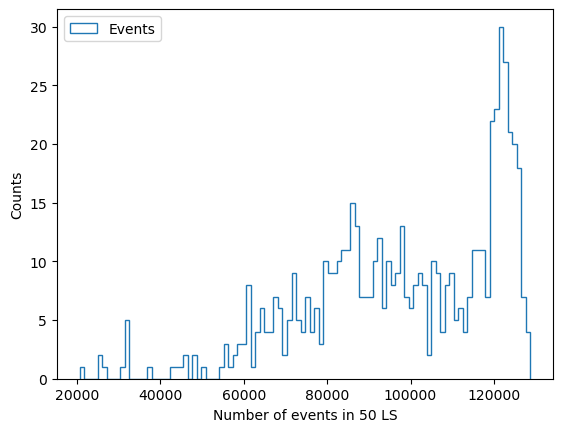

In [15]:
plt.hist(df['event_y'], bins=100, histtype='step', label='Events')
# plt.hist(df['nlumis'], bins=100, histtype='step', label='Nlumis')
plt.xlabel('Number of events in 50 LS')
plt.ylabel('Counts')
# plt.yscale('log')
plt.legend()

In [16]:
df['Ratio'] = df['event_y'] / df['lumi_y'] 
df['Ratio_err'] = df['Ratio'] * np.sqrt((df['event_y_error']/df['event_y'])**2 + 0.013**2)

In [17]:
df

,run,lumiblock,x_label,event_y,event_y_error,lumi_y,pileup_y,nlumis,chi2,alpha,...,nbkg,nbkg_err,nsig,nsig_err,sigma,sigma_err,sigma2,sigma2_err,Ratio,Ratio_err
1,367770,50,367770_50,63022.912446,427.678047,194.853451,26.488000,50,1.490106,1.856819,...,9724.213646,359.880516,63022.912446,427.678047,0.021623,0.000380,0.042716,0.000697,323.437497,4.743085
2,367770,100,367770_100,91968.216527,629.334435,298.582655,40.622000,50,2.013184,1.880378,...,15350.932033,565.142491,91968.216527,629.334435,0.021713,0.000326,0.043062,0.000719,308.015938,4.525068
3,367770,150,367770_150,113304.236328,467.997008,400.658978,56.110204,49,2.329863,1.646826,...,19704.582831,354.132429,113304.236328,467.997008,0.021514,0.000301,0.041455,0.000578,282.794702,3.857434
4,367771,0,367771_0,122131.451116,440.764989,452.831822,62.571429,49,2.231128,1.671848,...,22050.568920,306.574939,122131.451116,440.764989,0.021745,0.000269,0.041907,0.000547,269.705982,3.638777
5,367771,50,367771_50,105649.432252,1645.745353,447.899045,61.623810,42,2.839219,1.931081,...,17483.320224,1676.624558,105649.432252,1645.745353,0.021832,0.000256,0.042347,0.000873,235.877780,4.785797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,368822,750,368822_750,119979.207171,1058.914596,449.957601,60.976000,50,2.063010,1.919797,...,20015.271240,1059.865704,119979.207171,1058.914596,0.021425,0.000208,0.042612,0.000396,266.645584,4.189774
674,368822,800,368822_800,114440.909674,540.245535,432.364104,60.240000,50,2.093352,1.870138,...,19664.136230,443.920243,114440.909674,540.245535,0.021336,0.000292,0.041240,0.000556,264.686426,3.660771
675,368822,850,368822_850,115855.049182,1795.864981,429.896964,58.486000,50,1.746865,1.899831,...,18563.216249,1791.289272,115855.049182,1795.864981,0.021478,0.000305,0.042059,0.000891,269.494923,5.452062
676,368822,900,368822_900,108841.939964,944.342346,405.172337,56.618367,49,1.893992,1.897261,...,17336.349212,975.721927,108841.939964,944.342346,0.021572,0.000189,0.042064,0.000377,268.631222,4.198541


In [18]:
ROOT.gROOT.SetBatch(True)

fit_run = []
fit_slope = []
fit_slope_err = []
fit_const = []
fit_const_err = []

for run_number, group in df.groupby('run'):
    # ignore short runs
    if len(group) < 10:
        continue

    # Prepare data
    x = group['lumi_y'].values.astype(float)
    y = group['Ratio'].values.astype(float)
    y_err = group['Ratio_err'].values.astype(float)
    x_err = np.zeros_like(x)

    # Create TGraphErrors
    graph = ROOT.TGraphErrors(len(x), x, y, x_err, y_err)
    graph.SetTitle(f"Run {run_number}")
    graph.GetXaxis().SetTitle("Instantaneous Luminosity in 50 LS (nb^{-1})")
    graph.GetYaxis().SetTitle("Ratio J/#psi count to Instantaneous Luminosity in 50 LS")
    graph.SetMarkerStyle(20)
    graph.SetMarkerSize(1)

    # Fit with linear function
    fit_func = ROOT.TF1("fit_func", "pol1", min(x), max(x))
    fit_result = graph.Fit(fit_func, "QS")  # Q: quiet, S: returns fit result

    # Get fit parameters and stats
    p0 = fit_func.GetParameter(0)
    p0_err = fit_func.GetParError(0)
    p1 = fit_func.GetParameter(1)
    p1_err = fit_func.GetParError(1)
    chi2 = fit_func.GetChisquare()
    ndf = fit_func.GetNDF()
    red_chi2 = chi2 / ndf if ndf != 0 else 0

    fit_run.append(run_number)
    fit_slope.append(p1)
    fit_slope_err.append(p1_err)
    fit_const.append(p0)
    fit_const_err.append(p0_err)

    # Create canvas and draw
    canvas = ROOT.TCanvas(f"c_{run_number}", f"Run {run_number}", 800, 600)
    canvas.SetLeftMargin(0.15)  # Increase left margin for y-label
    graph.Draw("AP")
    fit_func.Draw("Same")

    # Prepare fit info box
    stats_text = ROOT.TPaveText(0.35, 0.75, 0.89, 0.9, "NDC")
    stats_text.SetFillColor(0)  # Transparent fill
    stats_text.SetFillStyle(0)  # Transparent fill style
    stats_text.SetBorderSize(0) # Remove border
    stats_text.SetTextAlign(13)
    stats_text.SetTextSize(0.030)  # Adjust text size if needed
    stats_text.AddText(f"y = ({p0:.3e} #pm {p0_err:.1e}) + ({p1:.3e} #pm {p1_err:.1e}) * x")
    stats_text.AddText(f"#chi^{{2}} / ndf = {chi2:.2f} / {ndf} = {red_chi2:.2f}")
    stats_text.Draw()

    canvas.Update()
    canvas.SaveAs(f"plots/ratio_fits/fit_run_{run_number}.png")


Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367836.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367838.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367840.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367883.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367884.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_367910.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_368229.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_368382.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_368388.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_368410.png has been created
Info in <TCanvas::Print>: png file plots/ratio_fits/fit_run_368454.png has been created
Info in <TCanvas::Print>: png fi

In [19]:
summary_df = pd.DataFrame({
    'fit_run': fit_run,
    'fit_slope': fit_slope,
    'fit_slope_err': fit_slope_err,
    'fit_const': fit_const,
    'fit_const_err': fit_const_err,
})

In [34]:
avg_slope, avg_slope_err = weighted_average(
    summary_df['fit_slope'].values, 
    summary_df['fit_slope_err'].values
)


avg_const, avg_const_err = weighted_average(
    summary_df['fit_const'].values, 
    summary_df['fit_const_err'].values
)

<function matplotlib.pyplot.plot(*args, scalex=True, scaley=True, data=None, **kwargs)>

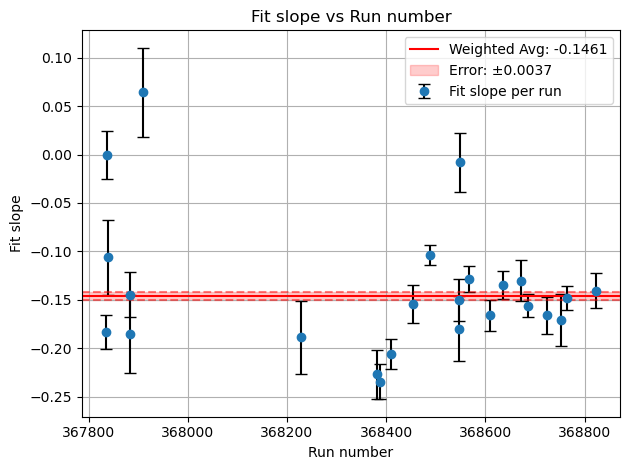

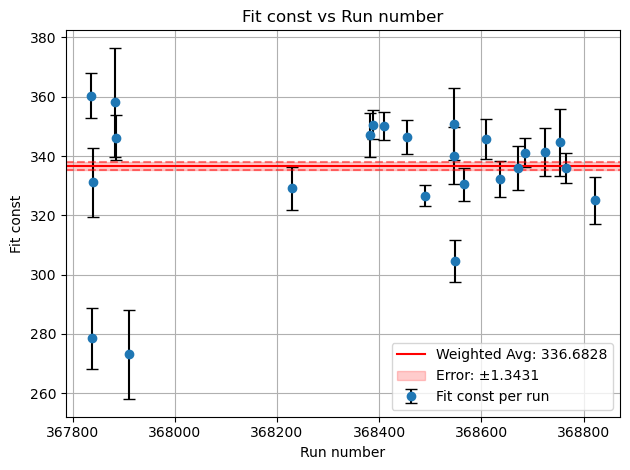

<Figure size 640x480 with 0 Axes>

In [35]:
plt.errorbar(
    summary_df['fit_run'],
    summary_df['fit_slope'],
    yerr=summary_df['fit_slope_err'],
    fmt='o',
    ecolor='black',
    capsize=4,
    label='Fit slope per run'
)
# Add the weighted average as a horizontal line
plt.axhline(y=avg_slope, color='r', linestyle='-', label=f'Weighted Avg: {avg_slope:.4f}')

# Add horizontal lines for the error bounds (optional)
plt.axhline(y=avg_slope+avg_slope_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_slope-avg_slope_err, color='r', linestyle='--', alpha=0.5)

# Add shaded error region (alternative to dashed lines)
plt.axhspan(avg_slope-avg_slope_err, avg_slope+avg_slope_err, 
            alpha=0.2, color='r', label=f'Error: ±{avg_slope_err:.4f}')

plt.xlabel('Run number')
plt.ylabel('Fit slope')
plt.title('Fit slope vs Run number')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig('plots/summary_slope.png')

plt.figure()
plt.errorbar(
    summary_df['fit_run'],
    summary_df['fit_const'],
    yerr=summary_df['fit_const_err'],
    fmt='o',
    ecolor='black',
    capsize=4,
    label='Fit const per run'
)
# Add the weighted average as a horizontal line
plt.axhline(y=avg_const, color='r', linestyle='-', label=f'Weighted Avg: {avg_const:.4f}')

# Add horizontal lines for the error bounds (optional)
plt.axhline(y=avg_const+avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_const-avg_const_err, color='r', linestyle='--', alpha=0.5)

# Add shaded error region (alternative to dashed lines)
plt.axhspan(avg_const-avg_const_err, avg_const+avg_const_err, 
            alpha=0.2, color='r', label=f'Error: ±{avg_const_err:.4f}')

plt.xlabel('Run number')
plt.ylabel('Fit const')
plt.title('Fit const vs Run number')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig('plots/summary_const.png')

plt.figure()
plt.plot

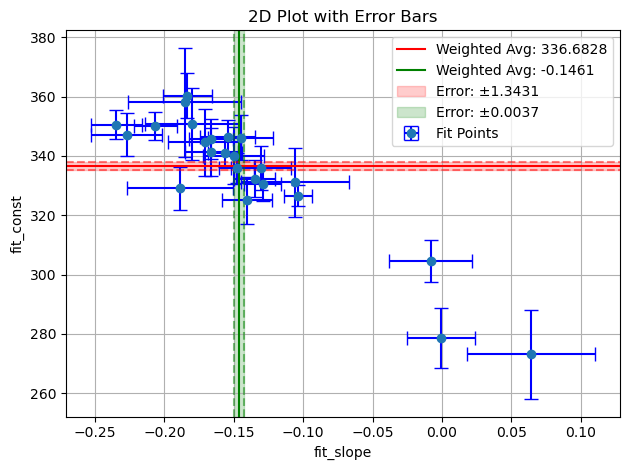

In [36]:
plt.errorbar(fit_slope, fit_const, 
             xerr=fit_slope_err, yerr=fit_const_err, 
             fmt='o', ecolor='blue', capsize=5, label='Fit Points')

# Label axes
plt.xlabel('fit_slope')
plt.ylabel('fit_const')
plt.title('2D Plot with Error Bars')
plt.grid(True)
plt.axhline(y=avg_const, color='r', linestyle='-', label=f'Weighted Avg: {avg_const:.4f}')
plt.axvline(x=avg_slope, color='g', linestyle='-', label=f'Weighted Avg: {avg_slope:.4f}')
plt.axhline(y=avg_const+avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=avg_const-avg_const_err, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=avg_slope+avg_slope_err, color='g', linestyle='--', alpha=0.5)
plt.axvline(x=avg_slope-avg_slope_err, color='g', linestyle='--', alpha=0.5)
plt.axhspan(avg_const-avg_const_err, avg_const+avg_const_err,
            alpha=0.2, color='r', label=f'Error: ±{avg_const_err:.4f}')
plt.axvspan(avg_slope-avg_slope_err, avg_slope+avg_slope_err,
            alpha=0.2, color='g', label=f'Error: ±{avg_slope_err:.4f}')

plt.legend()
# plt.xlim(-0.010, -0.00)
# plt.ylim(12, 14.5)
plt.tight_layout()
plt.savefig('plots/summary_2D.png')

In [37]:
# scale events to match lumi
scale_factor = sum(df['lumi_y']) / sum(df['event_y'])
scaled_event_y = [y * scale_factor for y in df['event_y']]
scale_factor

0.003535607873542145

In [38]:
df

,run,lumiblock,x_label,event_y,event_y_error,lumi_y,pileup_y,nlumis,chi2,alpha,...,nbkg,nbkg_err,nsig,nsig_err,sigma,sigma_err,sigma2,sigma2_err,Ratio,Ratio_err
1,367770,50,367770_50,63022.912446,427.678047,194.853451,26.488000,50,1.490106,1.856819,...,9724.213646,359.880516,63022.912446,427.678047,0.021623,0.000380,0.042716,0.000697,323.437497,4.743085
2,367770,100,367770_100,91968.216527,629.334435,298.582655,40.622000,50,2.013184,1.880378,...,15350.932033,565.142491,91968.216527,629.334435,0.021713,0.000326,0.043062,0.000719,308.015938,4.525068
3,367770,150,367770_150,113304.236328,467.997008,400.658978,56.110204,49,2.329863,1.646826,...,19704.582831,354.132429,113304.236328,467.997008,0.021514,0.000301,0.041455,0.000578,282.794702,3.857434
4,367771,0,367771_0,122131.451116,440.764989,452.831822,62.571429,49,2.231128,1.671848,...,22050.568920,306.574939,122131.451116,440.764989,0.021745,0.000269,0.041907,0.000547,269.705982,3.638777
5,367771,50,367771_50,105649.432252,1645.745353,447.899045,61.623810,42,2.839219,1.931081,...,17483.320224,1676.624558,105649.432252,1645.745353,0.021832,0.000256,0.042347,0.000873,235.877780,4.785797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,368822,750,368822_750,119979.207171,1058.914596,449.957601,60.976000,50,2.063010,1.919797,...,20015.271240,1059.865704,119979.207171,1058.914596,0.021425,0.000208,0.042612,0.000396,266.645584,4.189774
674,368822,800,368822_800,114440.909674,540.245535,432.364104,60.240000,50,2.093352,1.870138,...,19664.136230,443.920243,114440.909674,540.245535,0.021336,0.000292,0.041240,0.000556,264.686426,3.660771
675,368822,850,368822_850,115855.049182,1795.864981,429.896964,58.486000,50,1.746865,1.899831,...,18563.216249,1791.289272,115855.049182,1795.864981,0.021478,0.000305,0.042059,0.000891,269.494923,5.452062
676,368822,900,368822_900,108841.939964,944.342346,405.172337,56.618367,49,1.893992,1.897261,...,17336.349212,975.721927,108841.939964,944.342346,0.021572,0.000189,0.042064,0.000377,268.631222,4.198541


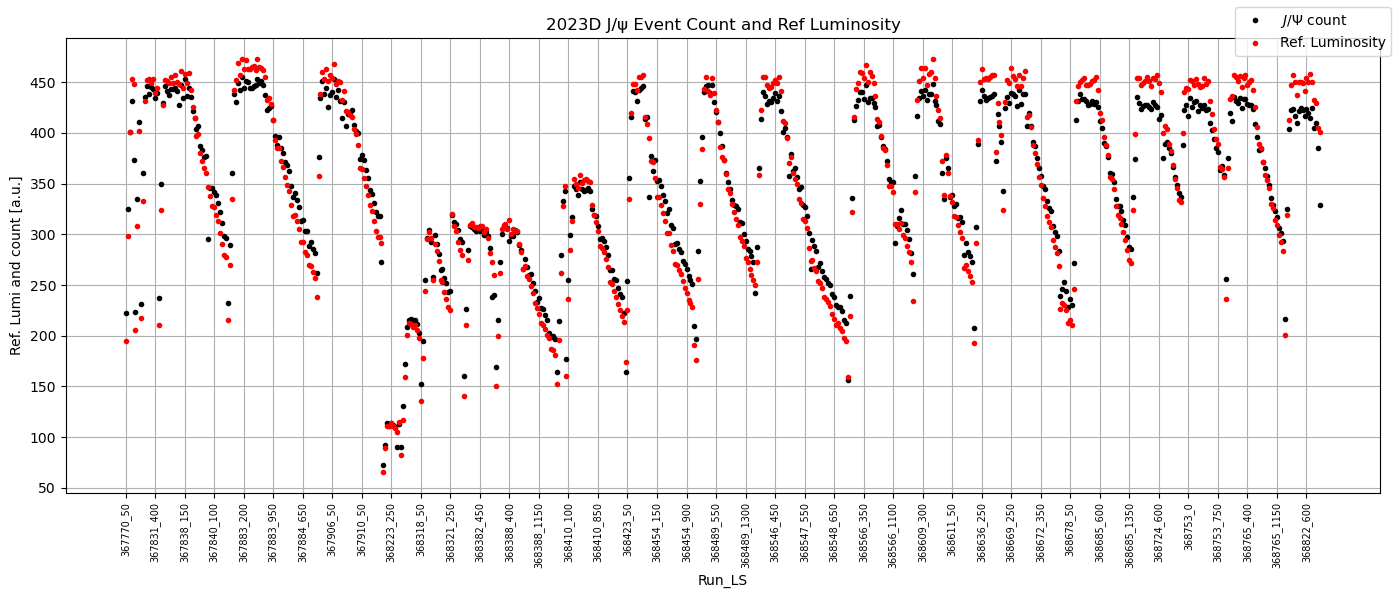

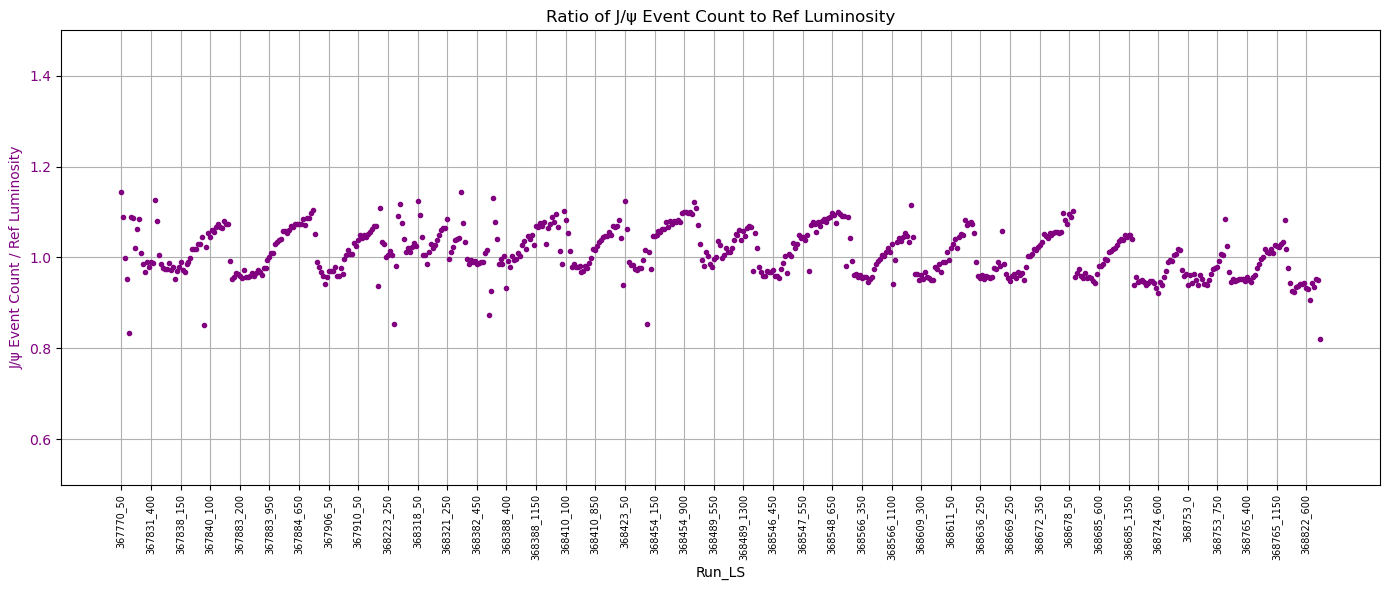

In [39]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(range(len(df['x_label'])), scaled_event_y, label="$J/ \Psi$ count", color="black", marker='.', linestyle='none')
ax1.plot(range(len(df['x_label'])), df['lumi_y'], label="Ref. Luminosity", color="red", marker='.', linestyle='none')
ax1.set_xlabel("Run_LS")
ax1.set_ylabel("Ref. Lumi and count [a.u.]", color="black")
ax1.tick_params(axis='y', labelcolor="black")

ax1.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax1.get_xticks() if 0 <= tick < len(df)]
ax1.set_xticks(visible_ticks)
ax1.set_xticklabels(df.iloc[visible_ticks]['x_label'], rotation=90, fontsize=7)

ax1.grid(True)
fig.legend(loc='upper right')
plt.title("2023D J/ψ Event Count and Ref Luminosity")
fig.tight_layout()
plt.savefig("plots/Jpsi.png", dpi=300)

# Compute ratio safely (avoid division by zero)
event_y_arr = np.array(scaled_event_y)
lumi_y_arr = np.array(df['lumi_y'])
ratio = np.zeros_like(lumi_y_arr)
nonzero_mask = event_y_arr != 0
ratio[nonzero_mask] = event_y_arr[nonzero_mask] / lumi_y_arr[nonzero_mask]

# Plot the ratio
fig2, ax3 = plt.subplots(figsize=(14, 6))
ax3.plot(range(len(df['x_label'])), ratio, color="purple", marker='.', linestyle='none')
ax3.set_xlabel("Run_LS")
ax3.set_ylabel("J/ψ Event Count / Ref Luminosity", color="purple")
ax3.tick_params(axis='y', labelcolor="purple")

ax3.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax3.get_xticks() if 0 <= tick < len(df)]
ax3.set_xticks(visible_ticks)
ax3.set_xticklabels(df.iloc[visible_ticks]['x_label'], rotation=90, fontsize=7)


ax3.grid(True)
plt.title("Ratio of J/ψ Event Count to Ref Luminosity")
plt.ylim(0.5, 1.5)
fig2.tight_layout()
plt.savefig("plots/Jpsi_ratio.png", dpi=300)  

In [40]:
avg_slope, avg_const

(-0.14607377217187703, 336.6827927868488)

In [41]:
# avg_slope = -4.7E-3
# avg_const = 12.8 
# avg_slope = -0.032589
# avg_const = 91.484915

predicted_lumi_y = []
for i, y in enumerate(df['event_y']):
        # Calculate the predicted event count using the linear fit
        predicted_count = (-avg_const + np.sqrt(avg_const**2 + 4 * avg_slope * y) ) / (2 * avg_slope)
        predicted_lumi_y.append(predicted_count)

# scale predicted lumi to match lumi
scale_factor_pred = sum(df['lumi_y']/sum(predicted_lumi_y))
scaled_predicted_lumi_y = [y * scale_factor_pred for y in predicted_lumi_y]

In [42]:
scale_factor_pred

0.9973262107273434

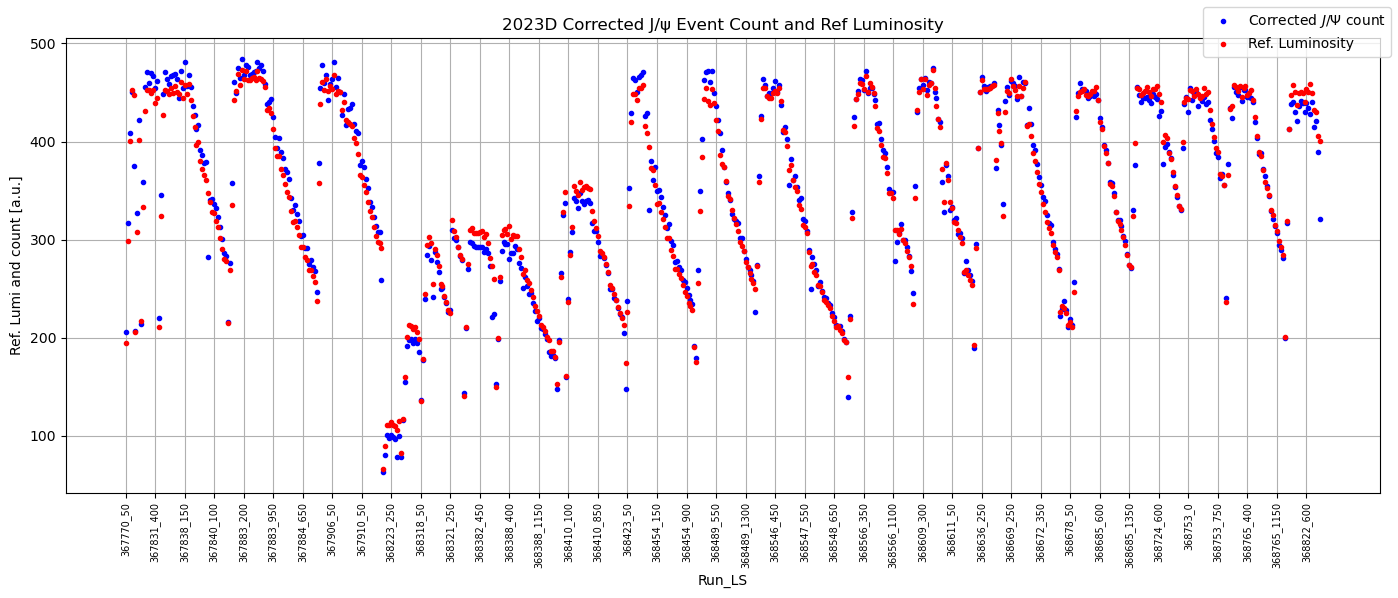

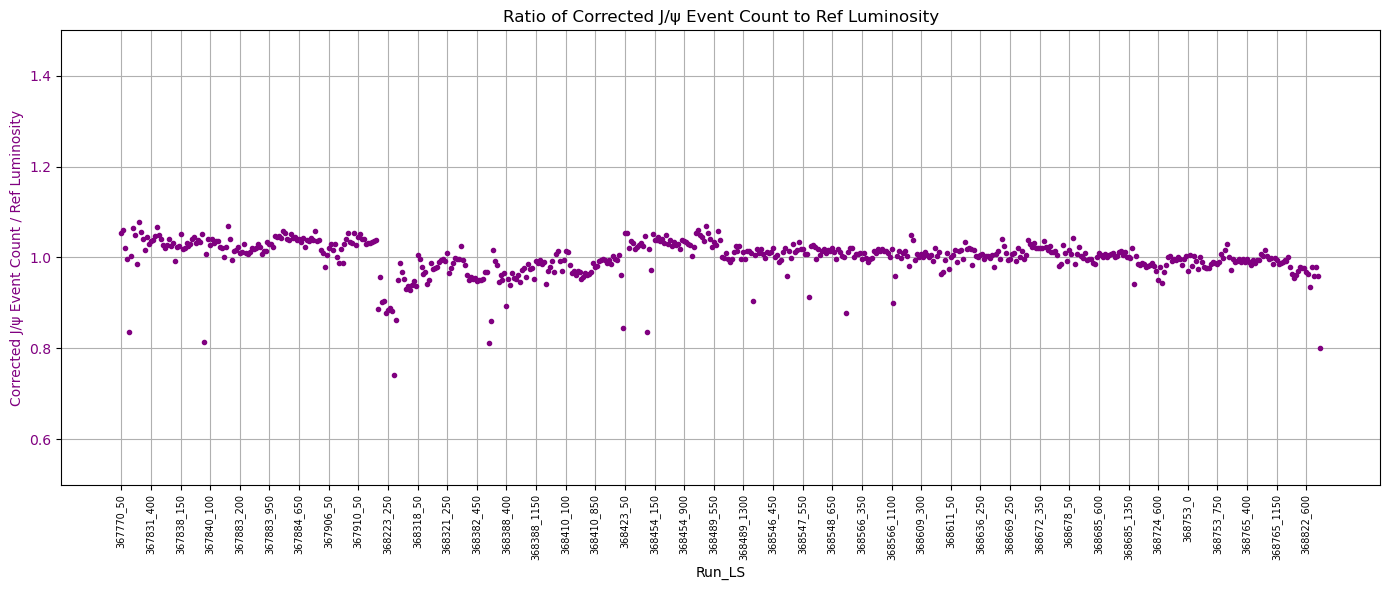

In [43]:
fig3, ax4 = plt.subplots(figsize=(14, 6))

# ax4.plot(range(len(df['x_label'])), scaled_event_y, label="$J/ \Psi$ count", color="black", marker='.', linestyle='none')
ax4.plot(range(len(df['x_label'])), predicted_lumi_y, label="Corrected $J/ \Psi$ count", color="blue", marker='.', linestyle='none')
ax4.plot(range(len(df['x_label'])), df['lumi_y'], label="Ref. Luminosity", color="red", marker='.', linestyle='none')
ax4.set_xlabel("Run_LS")
ax4.set_ylabel("Ref. Lumi and count [a.u.]", color="black")
ax4.tick_params(axis='y', labelcolor="black")


ax4.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax4.get_xticks() if 0 <= tick < len(df)]
ax4.set_xticks(visible_ticks)
ax4.set_xticklabels(df.iloc[visible_ticks]['x_label'], rotation=90, fontsize=7)

ax4.grid(True)
fig3.legend(loc='upper right')
plt.title("2023D Corrected J/ψ Event Count and Ref Luminosity")
fig3.tight_layout()
plt.savefig("plots/Jpsi_after.png", dpi=300)


# Compute ratio safely (avoid division by zero)
event_y_arr = np.array(predicted_lumi_y)
lumi_y_arr = np.array(df['lumi_y'])
ratio_corr = event_y_arr / lumi_y_arr
# ratio = np.zeros_like(lumi_y_arr)
# nonzero_mask = event_y_arr != 0
# ratio[nonzero_mask] = event_y_arr[nonzero_mask] / lumi_y_arr[nonzero_mask]

# Plot the ratio
fig4, ax5 = plt.subplots(figsize=(14, 6))
ax5.plot(range(len(df['x_label'])), ratio_corr, color="purple", marker='.', linestyle='none')
ax5.set_xlabel("Run_LS")
ax5.set_ylabel("Corrected J/ψ Event Count / Ref Luminosity", color="purple")
ax5.tick_params(axis='y', labelcolor="purple")

ax5.xaxis.set_major_locator(ticker.MaxNLocator(50))
visible_ticks = [int(tick) for tick in ax5.get_xticks() if 0 <= tick < len(df)]
ax5.set_xticks(visible_ticks)
ax5.set_xticklabels(df.iloc[visible_ticks]['x_label'], rotation=90, fontsize=7)

ax5.grid(True)
plt.title("Ratio of Corrected J/ψ Event Count to Ref Luminosity")
plt.ylim(0.5, 1.5)
fig4.tight_layout()
plt.savefig("Jpsi_ratio_after.png", dpi=300)  

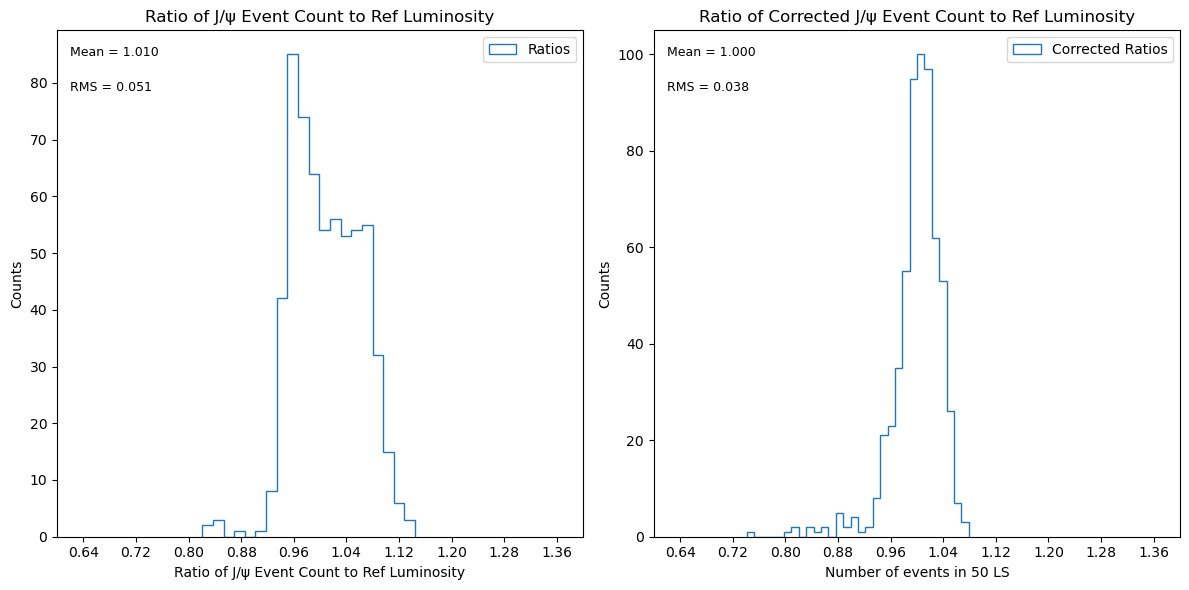

In [44]:
# Compute mean and RMS for both ratios
mean_ratio = np.mean(ratio)
rms_ratio = np.std(ratio)

mean_ratio_corr = np.mean(ratio_corr)
rms_ratio_corr = np.std(ratio_corr)

# Plot the two histograms
fig5, (ax6, ax7) = plt.subplots(1, 2, figsize=(12, 6))

# First histogram
ax6.hist(ratio, bins=20, histtype='step', label='Ratios')
ax6.set_xlabel('Ratio of J/ψ Event Count to Ref Luminosity')
ax6.set_ylabel('Counts')
ax6.legend()
ax6.set_title("Ratio of J/ψ Event Count to Ref Luminosity")
ax6.set_xlim(0.6, 1.4)
ax6.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax6.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Annotate mean and RMS on the first plot
ax6.text(0.62, 0.95 * ax6.get_ylim()[1], f"Mean = {mean_ratio:.3f}", fontsize=9)
ax6.text(0.62, 0.88 * ax6.get_ylim()[1], f"RMS = {rms_ratio:.3f}", fontsize=9)

# Second histogram
ax7.hist(ratio_corr, bins=30, histtype='step', label='Corrected Ratios')
ax7.set_xlabel('Number of events in 50 LS')
ax7.set_ylabel('Counts')
ax7.legend()
ax7.set_title("Ratio of Corrected J/ψ Event Count to Ref Luminosity")
ax7.set_xlim(0.6, 1.4)
ax7.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax7.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

# Annotate mean and RMS on the second plot
ax7.text(0.62, 0.95 * ax7.get_ylim()[1], f"Mean = {mean_ratio_corr:.3f}", fontsize=9)
ax7.text(0.62, 0.88 * ax7.get_ylim()[1], f"RMS = {rms_ratio_corr:.3f}", fontsize=9)

# Save the figure
plt.tight_layout()
plt.savefig("plots/Jpsi_ratio_hist.png", dpi=300)

In [45]:
import ROOT
import numpy as np

# Prepare data
data_array = np.array(ratio_corr, dtype=np.float64)

# Define RooFit variables
x = ROOT.RooRealVar("x", "Ratio", 0.9, 1.1)
data = ROOT.RooDataSet("data", "Dataset with ratios", ROOT.RooArgSet(x))

# Fill RooDataSet
for val in data_array:
    x.setVal(val)
    data.add(ROOT.RooArgSet(x))

# Define Gaussian model
mean = ROOT.RooRealVar("mean", "Mean", np.mean(data_array), 0.6, 1.4)
sigma = ROOT.RooRealVar("sigma", "Sigma", np.std(data_array), 0.001, 0.01)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

# Fit the model to the data
gauss.fitTo(data, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Verbose(False))

# Plot
frame = x.frame(ROOT.RooFit.Title("Gaussian Fit to Corrected J/#psi Ratio"))
data.plotOn(frame)
gauss.plotOn(frame)

# Add fitted parameters as text
fit_params = f"#mu = {mean.getVal():.3f},  #sigma = {sigma.getVal():.3f}"
latex = ROOT.TLatex(0.65, 0.85 * data.numEntries(), fit_params)
latex.SetNDC(False)
latex.SetTextSize(0.04)

# Draw
c = ROOT.TCanvas("c", "Fit", 800, 600)
frame.Draw()
latex.Draw()

# Save
c.SaveAs("plots/Jpsi_ratio_corr_roofit.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file plots/Jpsi_ratio_corr_roofit.png has been created


In [46]:
fit_params

'#mu = 1.002,  #sigma = 0.010'

In [47]:
import ROOT
import numpy as np

# Prepare data
data_array = np.array(ratio_corr, dtype=np.float64)

# Define RooFit variable and binning
x = ROOT.RooRealVar("x", "Ratio", 0.9, 1.1)
x.setBins(40)  # Set number of bins

# Create histogram and fill it
hist = ROOT.TH1D("hist", "Histogram of Corrected Ratios", 30, 0.6, 1.4)
for val in data_array:
    hist.Fill(val)

# Convert to RooDataHist (binned dataset)
data_binned = ROOT.RooDataHist("data_binned", "Binned dataset", ROOT.RooArgList(x), hist)

# Define Gaussian model
mean = ROOT.RooRealVar("mean", "Mean", np.mean(data_array), 0.6, 1.4)
sigma = ROOT.RooRealVar("sigma", "Sigma", np.std(data_array), 0.001, 0.05)
gauss = ROOT.RooGaussian("gauss", "Gaussian PDF", x, mean, sigma)

# Fit the model to the binned data
gauss.fitTo(data_binned, ROOT.RooFit.PrintLevel(-1), ROOT.RooFit.Verbose(False))

# Plot
frame = x.frame(ROOT.RooFit.Title("Binned Gaussian Fit to Corrected J/#psi Ratio"))
data_binned.plotOn(frame)
gauss.plotOn(frame)

# Add fitted parameters as text
fit_params = f"#mu = {mean.getVal():.3f},  #sigma = {sigma.getVal():.3f}"
latex = ROOT.TLatex(0.92, 0.9 * hist.GetMaximum(), fit_params)
latex.SetNDC(False)
latex.SetTextSize(0.04)

# Draw
c = ROOT.TCanvas("c", "Binned Fit", 800, 600)
frame.Draw()
latex.Draw()

# Save
c.SaveAs("plots/Jpsi_ratio_corr_roofit_binned.png")


Warning in <TROOT::Append>: Replacing existing TH1: hist (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file plots/Jpsi_ratio_corr_roofit_binned.png has been created
